In [1]:
import pandas as pd
import numpy as np
import os
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, TensorDataset
from tensorflow import keras
import tensorflow_probability as tfp

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

import geopandas as gpd
from shapely.geometry import Point
from geopandas import GeoDataFrame

from scipy.stats.stats import pearsonr
from geopy.distance import geodesic

from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from collections import defaultdict
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from geopy.distance import geodesic

from mapie.regression import MapieQuantileRegressor
from scipy.stats import randint, uniform

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

from sklearn.linear_model import Lasso
from scipy.optimize import linprog
from scipy.optimize import minimize

import pyreadr
import random

import seaborn as sns
import contextily as ctx
import tensorflow as tf

import keras_tuner as kt

2025-01-21 01:28:46.194579: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/var/folders/19/b_t4kk7x6cs9yr5g7mhxmk1c0000gp/T/ipykernel_5004/4011320821.py:34: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr


In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

In [ ]:
########################## Boston Housing Dataset ####################################################

In [4]:
housing_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/Standard_regression/BostonHousing/BostonHousing.csv")

In [5]:
housing_df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

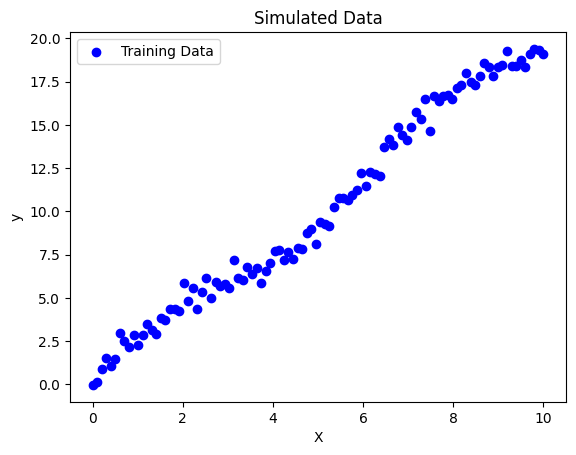

In [8]:
# Generate simulated data

np.random.seed(42)  # For reproducibility
X = np.linspace(0, 10, 100).reshape(-1, 1)  # Input features
y = 2.0 * X.flatten() + np.sin(X.flatten()) + np.random.normal(0, 0.5, size=X.shape[0])  # Output values

# Add some noise for realism
y += np.random.normal(0, 0.2, size=y.shape)

# Plot the data
plt.scatter(X, y, color="blue", label="Training Data")
plt.title("Simulated Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [9]:
# Define the Gaussian Process model with a kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.5**2)

# Fit the model to the data
gp.fit(X, y)

# Predict on new data
X_pred = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred, y_std = gp.predict(X_pred, return_std=True)


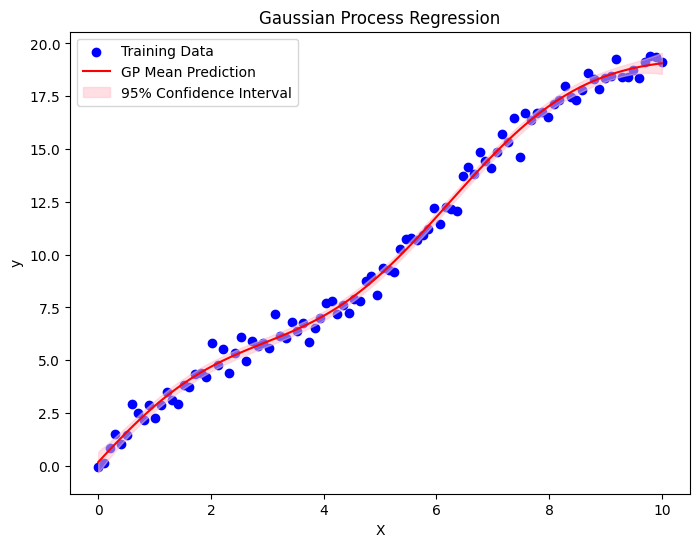

In [10]:
# Plot predictions with confidence intervals
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color="blue", label="Training Data")
plt.plot(X_pred, y_pred, color="red", label="GP Mean Prediction")
plt.fill_between(
    X_pred.flatten(),
    y_pred - 1.96 * y_std,
    y_pred + 1.96 * y_std,
    color="pink",
    alpha=0.5,
    label="95% Confidence Interval"
)
plt.title("Gaussian Process Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [6]:
# Features and target
X = housing_df.drop(columns=['medv'])
y = housing_df['medv']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features for better Gaussian Process performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale = 1.0, length_scale_bounds = (1e-3, 1e3))

# Initialize the Gaussian Process Regressor
gp = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = 50, alpha = 0.95)

# Fit the model on the training data
gp.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred, y_std = gp.predict(X_test_scaled, return_std=True)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 12.89
R^2 Score: 0.82


In [24]:
# Define the kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-3, 1e3))

# Define the negative log marginal likelihood
def nll(params, X_train, y_train):
    
    """Negative log marginal likelihood."""
    length_scale, signal_variance, noise_variance = params
    kernel = C(signal_variance, (1e-3, 1e3)) * RBF(length_scale, (1e-3, 1e3))
    gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_variance, optimizer=None)
    gp.fit(X_train, y_train)
    
    return -gp.log_marginal_likelihood_value_

# Optimize hyperparameters using EM
def optimize_gpr_em(X_train, y_train):
    """Perform EM optimization for GPR hyperparameters."""
    initial_params = [0.99, 0.98, 0.95]  # Initial guesses: length_scale, signal_variance, noise_variance

    # Minimize the negative log-likelihood
    bounds = [(1e-3, 1e3), (1e-2, 1e2), (1e-1, 1e1)]
    res = minimize(nll, initial_params, args=(X_train, y_train), bounds=bounds, method='L-BFGS-B')

    return res.x  # Optimized parameters

# Optimize kernel hyperparameters
optimized_params = optimize_gpr_em(X_train_scaled, y_train)
length_scale, signal_variance, noise_variance = optimized_params

print(f"Optimized Length Scale: {length_scale:.3f}")
print(f"Optimized Signal Variance: {signal_variance:.3f}")
print(f"Optimized Noise Variance: {noise_variance:.3f}")

# Define and fit the optimized Gaussian Process model
optimized_kernel = C(signal_variance, (1e-3, 1e3)) * RBF(length_scale, (1e-3, 1e3))
gp = GaussianProcessRegressor(kernel=optimized_kernel, alpha=noise_variance, n_restarts_optimizer=10)
gp.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred, y_std = gp.predict(X_test_scaled, return_std=True)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Optimized Length Scale: 3.179
Optimized Signal Variance: 100.000
Optimized Noise Variance: 5.538
Mean Squared Error: 10.99
R^2 Score: 0.85


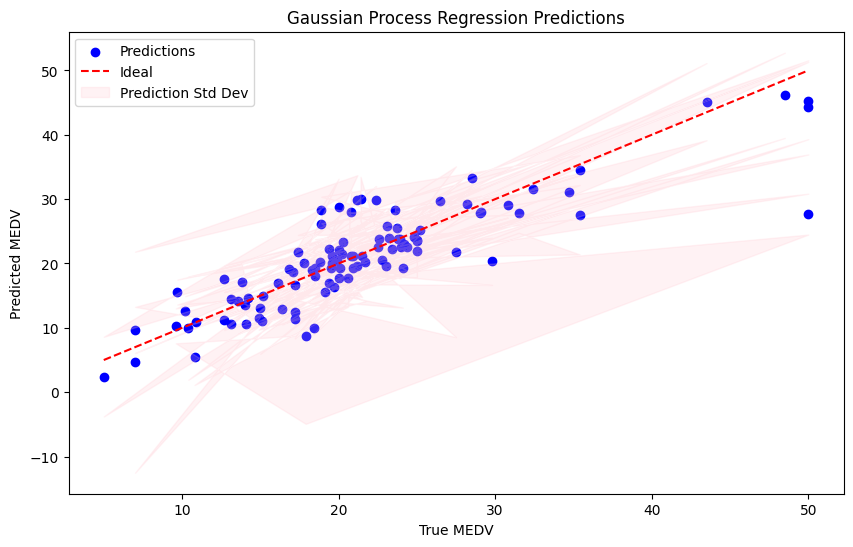

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color="blue", label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Ideal")
plt.fill_between(y_test, y_pred - y_std, y_pred + y_std, color="pink", alpha=0.2, label="Prediction Std Dev")
plt.title("Gaussian Process Regression Predictions")
plt.xlabel("True MEDV")
plt.ylabel("Predicted MEDV")
plt.legend()
plt.show()

In [ ]:
import xgboost as xgb

# Initialize the XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=100,    # Number of trees
    learning_rate=0.1,   # Step size shrinkage
    max_depth=5,         # Maximum tree depth
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

In [7]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest regressor
rf_model = RandomForestRegressor(
    n_estimators=100,  # Number of trees
    max_depth=10,      # Maximum depth of trees
    random_state=42    # For reproducibility
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 7.76
R^2 Score: 0.89


In [ ]:
############################## US PM 2.5 Data ##############################

In [4]:
us_sensors_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/US_data/us_monitoring_full.csv")

In [5]:
us_sensors_df = us_sensors_df[['day', 'month', 'cmaq_x', 'cmaq_y', 'cmaq_id', 'lon', 'lat', 'rid', 'elev',
       'forest_cover', 'pd', 'local', 'limi', 'high', 'is', 'nldas_pevapsfc',
       'nldas_pressfc', 'nldas_cape', 'nldas_ugrd10m', 'nldas_vgrd10m',
       'nldas_tmp2m', 'nldas_rh2m', 'nldas_dlwrfsfc', 'nldas_dswrfsfc',
       'nldas_pcpsfc', 'nldas_fpcsfc', 'gc_aod', 'aod_value', 'emissi11_pm25',
       'pm25_value']]

In [6]:
us_sensors_df.columns

Index(['day', 'month', 'cmaq_x', 'cmaq_y', 'cmaq_id', 'lon', 'lat', 'rid',
       'elev', 'forest_cover', 'pd', 'local', 'limi', 'high', 'is',
       'nldas_pevapsfc', 'nldas_pressfc', 'nldas_cape', 'nldas_ugrd10m',
       'nldas_vgrd10m', 'nldas_tmp2m', 'nldas_rh2m', 'nldas_dlwrfsfc',
       'nldas_dswrfsfc', 'nldas_pcpsfc', 'nldas_fpcsfc', 'gc_aod', 'aod_value',
       'emissi11_pm25', 'pm25_value'],
      dtype='object')

/var/folders/19/b_t4kk7x6cs9yr5g7mhxmk1c0000gp/T/ipykernel_5004/201065626.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(regions))  # Use 'tab10' colormap for categorical data


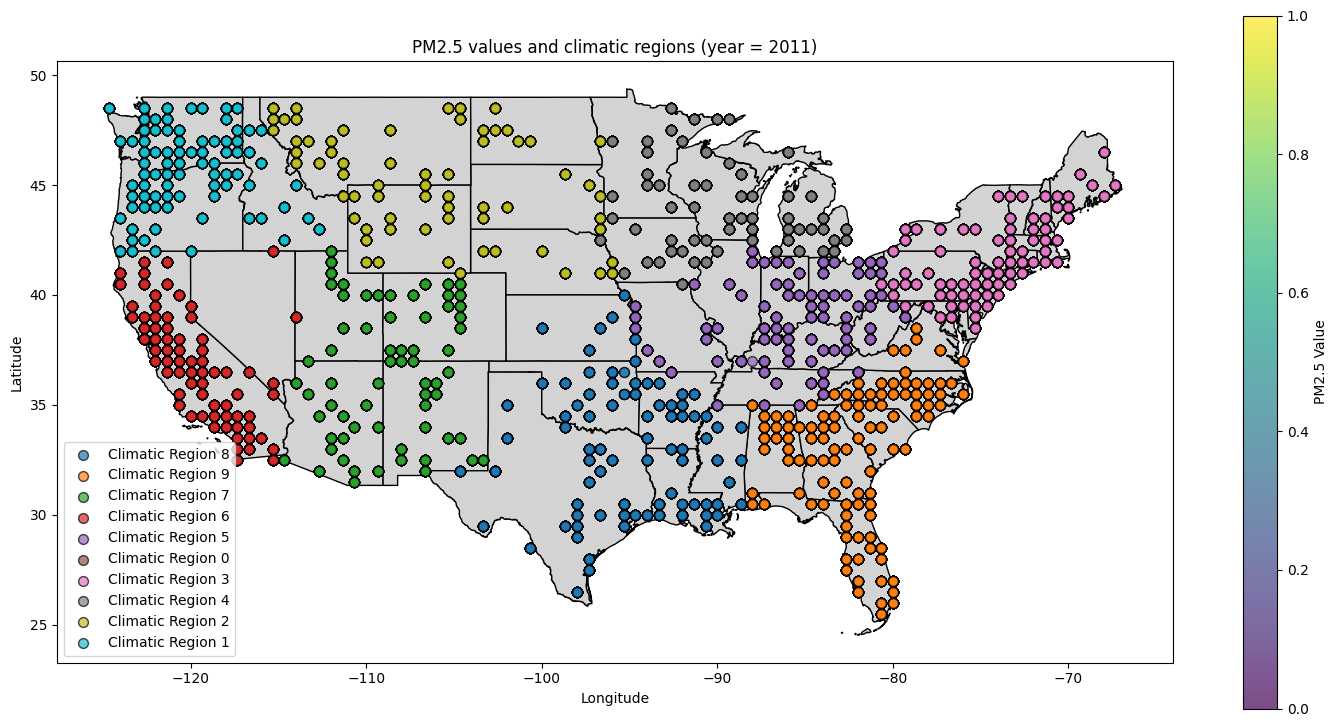

In [7]:
#### US plot with shape plot and climatic regions

# Load the shapefile using GeoPandas
shapefile_path = "/Users/shrey/Downloads/PM25/transfer-learning-propagation/data/Shape-files/cb_2018_us_state_5m/cb_2018_us_state_5m.shp"
us_shapefile = gpd.read_file(shapefile_path)

# Filter the shapefile to keep only the conterminous US (exclude Alaska, Hawaii, and territories)
conterminous_us = us_shapefile[~us_shapefile['STUSPS'].isin(['AK', 'HI', 'PR', 'GU', 'VI', 'AS', 'MP'])]

# Create a color map for the different climatic regions (assuming there are 10 regions)
regions = us_sensors_df['rid'].unique()
colors = plt.cm.get_cmap('tab10', len(regions))  # Use 'tab10' colormap for categorical data

# Create the figure and axis
fig, ax = plt.subplots(figsize=(18, 9))

# Plot the conterminous US shapefile
conterminous_us.plot(ax=ax, color='lightgray', edgecolor='black')

# Loop through each region and plot the points for that region
for i, region in enumerate(regions):
    region_data = us_sensors_df[us_sensors_df['rid'] == region]
    sc = ax.scatter(region_data['lon'], region_data['lat'], c=[colors(i)], 
               label=f'Climatic Region {region}', s=50, edgecolor='k', alpha=0.7)

# Add a colorbar for PM2.5 values
plt.colorbar(sc, label = 'PM2.5 Value')

# Add labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('PM2.5 values and climatic regions (year = 2011)')

# Add a legend to mark the different climatic regions
plt.legend(loc='lower left')

# Show the plot
plt.show()

In [16]:
# Step 1: Filter data where rid == 6
rid_6_data = us_sensors_df[us_sensors_df['rid'] == 6]

# Step 2: Drop the 'aod_value' column
rid_6_data = rid_6_data.drop(columns=['aod_value'])

# Step 3: Define features and target
X = rid_6_data.drop(columns=['pm25_value'])
y = rid_6_data['pm25_value']

# Step 4: Split the data into train-test sets (70:30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Normalize selected columns
# Columns NOT to normalize
exclude_columns = ['day', 'month', 'cmaq_x', 'cmaq_y', 'cmaq_id', 'lon', 'lat', 'rid']

# Identify columns to normalize
cols_to_normalize = [col for col in X_train.columns if col not in exclude_columns]

# Apply MinMaxScaler
scaler = MinMaxScaler()

# # Normalize only specified columns
# X_train_norm = X_train.copy()
# X_test_norm = X_test.copy()

# Normalize selected columns
X_train_norm = X_train.copy().reset_index(drop=True)  # Reset index after copying
X_test_norm = X_test.copy().reset_index(drop=True)   # Reset index after copying


X_train_norm[cols_to_normalize] = scaler.fit_transform(X_train[cols_to_normalize])
X_test_norm[cols_to_normalize] = scaler.transform(X_test[cols_to_normalize])

In [41]:
X_train_norm.columns

Index(['day', 'month', 'cmaq_x', 'cmaq_y', 'cmaq_id', 'lon', 'lat', 'rid',
       'elev', 'forest_cover', 'pd', 'local', 'limi', 'high', 'is',
       'nldas_pevapsfc', 'nldas_pressfc', 'nldas_cape', 'nldas_ugrd10m',
       'nldas_vgrd10m', 'nldas_tmp2m', 'nldas_rh2m', 'nldas_dlwrfsfc',
       'nldas_dswrfsfc', 'nldas_pcpsfc', 'nldas_fpcsfc', 'gc_aod',
       'emissi11_pm25'],
      dtype='object')

In [36]:
######### Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest regressor
rf_model = RandomForestRegressor(
    n_estimators = 200,  # Number of trees
    max_depth = 10,      # Maximum depth of trees
    random_state=42    # For reproducibility
)

# Train the model
rf_model.fit(X_train_norm, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test_norm)

# Evaluate the model
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 4.55
R^2 Score: 0.69


In [37]:
######### Gaussian Process Regression

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale = 1.0, length_scale_bounds = (1e-3, 1e3))

# Initialize the Gaussian Process Regressor
gp = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = 50, alpha = 0.95)

# Fit the model on the training data
gp.fit(X_train_norm, y_train)

# Predict on the test set
y_pred, y_std = gp.predict(X_test_norm, return_std=True)

# Evaluate the model
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fe238e47d90>>
Traceback (most recent call last):
  File "/Users/shrey/anaconda3/envs/python-310/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 

KeyboardInterrupt



In [43]:
#### Modify dataset to combine non-essential features.

def generate_combined_features(df):
    """
    Generate 3 new features using linear combinations:
    - `time_feature`: Linear combination of 'day' and 'month'.
    - `space_feature`: Linear combination of 'cmaq_x', 'cmaq_y', 'lon', and 'lat'.
    - `id_feature`: Linear combination of 'cmaq_id' and 'rid'.

    The original columns are dropped, and the new features are added to the DataFrame.

    Parameters:
        df (pd.DataFrame): Input DataFrame.

    Returns:
        pd.DataFrame: Modified DataFrame with the new features.
    """
    # Ensure required columns exist
    required_columns = ['day', 'month', 'cmaq_x', 'cmaq_y', 'cmaq_id', 'lon', 'lat', 'rid']
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in the DataFrame.")
    
    # Linear combinations with equal weights
    df['time_feature'] = 0.5 * df['day'] + 0.5 * df['month']
    df['space_feature'] = (
        0.25 * df['cmaq_x'] + 
        0.25 * df['cmaq_y'] + 
        0.25 * df['lon'] + 
        0.25 * df['lat']
    )
    df['id_feature'] = 0.5 * df['cmaq_id'] + 0.5 * df['rid']
    
    # Drop the original columns
    df = df.drop(columns=required_columns)

    return df

In [44]:
################ Sparse Gaussian Process

# Define the Sparse GP model
import gpytorch
from gpytorch.means import ConstantMean
from gpytorch.kernels import ScaleKernel, RBFKernel, InducingPointKernel
from gpytorch.distributions import MultivariateNormal
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import VariationalELBO
from gpytorch.variational import VariationalStrategy, CholeskyVariationalDistribution

In [ ]:
# def restart_training(model, likelihood, train_x, train_y, n_restarts = 10, iterations = 2000):
#     best_loss = float("inf")
#     best_state_dict = None

#     for restart in range(n_restarts):
#         # Reset model parameters
#         model.covar_module.initialize(outputscale=1.0) 
#         model.covar_module.base_kernel.initialize(lengthscale = 1.0, lengthscale_constraint=gpytorch.constraints.Interval(1e-4, 1e4))  

#         model.train()
#         likelihood.train()
#         optimizer = torch.optim.Adam(model.parameters(), lr = 0.98)

#         for i in range(iterations):
#             optimizer.zero_grad()
#             output = model(train_x)
#             loss = -mll(output, train_y)
#             loss.backward()
#             optimizer.step()

#             if i % 100 == 0:
#                 print(f"Restart {restart + 1}, Iter {i + 1}/{iterations} - Loss: {loss.item():.3f}")

#         # Save the best model
#         if loss.item() < best_loss:
#             best_loss = loss.item()
#             best_state_dict = model.state_dict()

#     # Load the best model parameters
#     model.load_state_dict(best_state_dict)
#     print(f"Best Loss After {n_restarts} Restarts: {best_loss:.3f}")

##### Assuming `data` is your dataset
inducing_points_df = (
    X_train_norm.groupby('cmaq_id')  # Group by `cmaq_id`
    .apply(lambda group: group.sample(n = 1))  # Randomly sample 1 row per group
    .reset_index(drop=True)  # Reset the index
)

print(inducing_points_df.shape)

X_train_modified = generate_combined_features(X_train_norm)
X_test_modified = generate_combined_features(X_test_norm)
inducing_points_modified = generate_combined_features(inducing_points_df)


print(X_train_modified.shape, X_test_modified.shape, inducing_points_modified.shape)


##### Initialize inducing points 
# inducing_points_tensor = torch.tensor(inducing_points_df.values, dtype=torch.float32)
inducing_points_tensor = torch.tensor(inducing_points_modified.values, dtype=torch.float32)


##### Convert data to tensors
# train_x = torch.tensor(X_train_norm.values, dtype=torch.float32)
# test_x = torch.tensor(X_test_norm.values, dtype=torch.float32)

train_x = torch.tensor(X_train_modified.values, dtype=torch.float32)
test_x = torch.tensor(X_test_modified.values, dtype=torch.float32)

train_y = torch.tensor(y_train.values, dtype=torch.float32)
test_y = torch.tensor(y_test.values, dtype=torch.float32)

##### Move data to GPU if available
if torch.cuda.is_available():
    train_x, train_y, test_x, test_y = train_x.cuda(), train_y.cuda(), test_x.cuda(), test_y.cuda()


class SparseGPRegressionModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = VariationalStrategy(self, inducing_points, variational_distribution, learn_inducing_locations=True)
        
        super(SparseGPRegressionModel, self).__init__(variational_strategy)
        self.mean_module = ConstantMean()
        self.covar_module = ScaleKernel(RBFKernel(lengthscale = 1.0, lengthscale_constraint = gpytorch.constraints.Interval(1e-2, 1e2)))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)


##### Instantiate the model and likelihood
model = SparseGPRegressionModel(inducing_points = inducing_points_tensor)
likelihood = GaussianLikelihood()

##### Move model and likelihood to GPU if available
if torch.cuda.is_available():
    model = model.cuda()
    likelihood = likelihood.cuda()

##### Define optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr = 0.98)
mll = VariationalELBO(likelihood, model, num_data = train_y.size(0))

##### Perform training with restarts
# restart_training(model, likelihood, train_x, train_y, n_restarts=50, iterations=2000)

##### Training loop
def train():
    model.train()
    likelihood.train()

    for i in range(1200):  
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        
        if i % 100 == 0:
            print(f"Iter {i + 1}/1200 - Loss: {loss.item():.3f}")

train()

##### Testing
model.eval()
likelihood.eval()

with torch.no_grad():
    predictions = likelihood(model(test_x))
    mean_pred = predictions.mean
    rmse = math.sqrt(mean_squared_error(test_y.cpu().numpy(), mean_pred.cpu().numpy()))
    r2 = r2_score(test_y.cpu().numpy(), mean_pred.cpu().numpy())

print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

/var/folders/19/b_t4kk7x6cs9yr5g7mhxmk1c0000gp/T/ipykernel_5004/2391969314.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n = 1))  # Randomly sample 1 row per group
/Users/shrey/anaconda3/envs/python-310/lib/python3.10/site-packages/gpytorch/distributions/multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-06.
  warnings.warn(


(128, 31)
(19453, 23) (8338, 23) (128, 23)
Iter 1/1200 - Loss: 137.557
Iter 101/1200 - Loss: 40.070
Iter 201/1200 - Loss: 36.877
Iter 301/1200 - Loss: 35.844
Iter 401/1200 - Loss: 35.517
Iter 501/1200 - Loss: 35.461
Iter 601/1200 - Loss: 35.428
Iter 701/1200 - Loss: 35.362
Iter 801/1200 - Loss: 35.317
Iter 901/1200 - Loss: 35.349
Iter 1001/1200 - Loss: 35.294
Iter 1101/1200 - Loss: 35.377


In [31]:
# Assuming `data` is your dataset
inducing_points_df = (
    X_train_norm.groupby('cmaq_id')  # Group by `cmaq_id`
    .apply(lambda group: group.sample(n=1))  # Randomly sample 1 row per group
    .reset_index(drop=True)  # Reset the index
)

print(inducing_points_df.shape)

# Initialize inducing points (e.g., 128 points from the training set)
inducing_points_tensor = torch.tensor(inducing_points_df.values, dtype=torch.float32)

# Convert data to tensors
train_x = torch.tensor(X_train_norm.values, dtype=torch.float32)
train_y = torch.tensor(y_train.values, dtype=torch.float32)
test_x = torch.tensor(X_test_norm.values, dtype=torch.float32)
test_y = torch.tensor(y_test.values, dtype=torch.float32)

# Move data to GPU if available
if torch.cuda.is_available():
    train_x, train_y, test_x, test_y = train_x.cuda(), train_y.cuda(), test_x.cuda(), test_y.cuda()


class GPRegressionModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(GPRegressionModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean()
        self.base_covar_module = ScaleKernel(RBFKernel())
        self.covar_module = InducingPointKernel(self.base_covar_module, inducing_points = inducing_points_tensor, likelihood=likelihood)

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = GPRegressionModel(train_x, train_y, likelihood)

if torch.cuda.is_available():
    model = model.cuda()
    likelihood = likelihood.cuda()

training_iterations = 100

# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.5)

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

def train():
    for i in range(training_iterations):
        # Zero backprop gradients
        optimizer.zero_grad()
        # Get output from model
        output = model(train_x)
        # Calc loss and backprop derivatives
        loss = -mll(output, train_y)
        loss.backward()
        print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iterations, loss.item()))
        optimizer.step()
        torch.cuda.empty_cache()

# See dkl_mnist.ipynb for explanation of this flag
%time train()

model.eval()
likelihood.eval()

with gpytorch.settings.max_preconditioner_size(10), torch.no_grad():
    preds = model(test_x)
    mean_preds = preds.mean
    rmse = math.sqrt(mean_squared_error(test_y.cpu().numpy(), mean_preds.cpu().numpy()))
    r2 = r2_score(test_y.cpu().numpy(), mean_preds.cpu().numpy())

print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

/var/folders/19/b_t4kk7x6cs9yr5g7mhxmk1c0000gp/T/ipykernel_5004/3985925360.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=1))  # Randomly sample 1 row per group
/Users/shrey/anaconda3/envs/python-310/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(


(128, 28)
Iter 1/100 - Loss: -14512.279
Iter 2/100 - Loss: -48387.934
Iter 3/100 - Loss: -114827.641
Iter 4/100 - Loss: -297098.219
Iter 5/100 - Loss: -325060.875
Iter 6/100 - Loss: -564655.938
Iter 7/100 - Loss: -3246568.500
Iter 8/100 - Loss: -2019255.375
Iter 9/100 - Loss: -5447851.000
Iter 10/100 - Loss: -12513214.000
Iter 11/100 - Loss: -14666317.000
Iter 12/100 - Loss: -32965868.000
Iter 13/100 - Loss: -69308624.000
Iter 14/100 - Loss: -38442096.000
Iter 15/100 - Loss: -165112320.000
Iter 16/100 - Loss: -129438896.000
Iter 17/100 - Loss: -287350816.000
Iter 18/100 - Loss: -823425984.000
Iter 19/100 - Loss: -861504448.000
Iter 20/100 - Loss: -1428159616.000
Iter 21/100 - Loss: -3695060992.000
Iter 22/100 - Loss: -4046592768.000
Iter 23/100 - Loss: -7087781376.000
Iter 24/100 - Loss: -6167730176.000
Iter 25/100 - Loss: -7645631488.000
Iter 26/100 - Loss: -12461424640.000
Iter 27/100 - Loss: -23442798592.000
Iter 28/100 - Loss: -14648706048.000
Iter 29/100 - Loss: -21201301504.000
I

NanError: cholesky_cpu: 16384 of 16384 elements of the torch.Size([128, 128]) tensor are NaN.

NanError: cholesky_cpu: 16384 of 16384 elements of the torch.Size([128, 128]) tensor are NaN.